PointNet Implementation for 3D Point Cloud Segmentation (Tensorflow)

* Dr. Jie Wie, Evan Perez, Kalelo Dukuray
* The City College of New York - Grove School of Engineering

* References:
 https://keras.io/examples/vision/pointnet_segmentation/

 https://medium.com/@sepideh.92sh/decoding-pointnet-a-practical-guide-to-3d-segmentation-with-python-and-pytorch-7a037fecb8a7

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install open3d giotto-tda laspy gudhi

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 81.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 457.9/457.9 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 

In [ ]:
import laspy, gudhi

from gtda.diagrams import (
    NumberOfPoints as NOP,
    Amplitude as APT,
    PersistenceEntropy as PSE,
)


In [ ]:
import os
import json
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from glob import glob

import tensorflow as tf
import keras
from keras import layers

import matplotlib.pyplot as plt


In [ ]:
import json

metadata = {
    'Airplane': {
        'directory': '02691156',
        'labels': ['wing', 'body', 'tail', 'engine'], 'colors': ['blue', 'green', 'red']
    }
}

#convert dictionary to JSON string
json_metadata = json.dumps(metadata, indent=4)

#print JSON string
print(json_metadata)

{
    "Airplane": {
        "directory": "02691156",
        "labels": [
            "wing",
            "body",
            "tail",
            "engine"
        ],
        "colors": [
            "blue",
            "green",
            "red"
        ]
    }
}


# PointNet


In [ ]:

#retrieve the points and labels for the p
points_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points".format(
    metadata["Airplane"]["directory"]
)
labels_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points_label".format(
    metadata["Airplane"]["directory"]
)
LABELS = metadata["Airplane"]["labels"]
COLORS = metadata["Airplane"]["colors"]

VAL_SPLIT = 0.2
NUM_SAMPLE_POINTS = 1024
BATCH_SIZE = 32
EPOCHS = 60
INITIAL_LR = 1e-3

In [ ]:
print(COLORS)

['blue', 'green', 'red']


In [ ]:
import os
import numpy as np

#define the directories and labels
points_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points"
labels_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points_label"
LABELS = metadata["Airplane"]["labels"]
COLORS = metadata["Airplane"]["colors"]


airplane_counts = 0
part_instance_counts = {part: 0 for part in LABELS}


print("Listing files in the points directory:")
for filename in os.listdir(points_dir):
    print(filename)

print("\nListing files in the labels directory:")
for filename in os.listdir(labels_dir):
    print(filename)

#iterate over the files in the point cloud directory
for filename in os.listdir(points_dir):
    if filename.endswith(".pts"):
        airplane_counts += 1
        #get the corresponding label file
        label_file = os.path.join(labels_dir, filename.replace(".pts", ".txt"))

        if os.path.exists(label_file):

            labels = np.loadtxt(label_file, dtype=int)

            unique, counts = np.unique(labels, return_counts=True)
            for label, count in zip(unique, counts):
                part_name = LABELS[label]
                part_instance_counts[part_name] += count
        else:
            print(f"Label file not found for {filename}")


print(f"\nTotal number of airplane samples (files): {airplane_counts}")
print("\nNumber of instances of each part across the entire dataset:")
for part, count in part_instance_counts.items():
    print(f"{part.capitalize()}: {count}")


Streaming output truncated to the last 5000 lines.
1e0a24e1135e75a831518807a840c4f4.pts
1e155559446469112e690fa6dfd5d610.pts
1df217928b39b927a8cba409c4409ba9.pts
1e358e70c047687a1a8831797284b67.pts
1deb997079e0b3cd6c1cd53dbc9f7b8e.pts
1e2de00cf19a0a33554ccf8c30febe7.pts
1e44b99c8de5eb01ebc54ed98d6399b2.pts
1e4fb40e5908f2bddf2f34e1100f0241.pts
1e40d41905a9be766ed8c57a1980bb26.pts
1e827425b289432e8b96ae1a0a8b84ec.pts
1e4bb798f236f0b17f1f82f6fc8747b8.pts
1e6a71e0cb436a88a3a1394d6e3d2c63.pts
1e7dbf0057e067586e88b250ea6544d0.pts
1e9ef313876bfba7d02c6d35cc802839.pts
1e9acb74ad09ba97192ddbe75f0b85fe.pts
1eb1d7d471f3c4c0634efb708169415.pts
1ea7a36e4f353416fe1f6e05091d5d9.pts
1e8adc1e176bc68571d03b466c72ce41.pts
1e8c56bac4e66672e85e222f6559b47.pts
1ea8a685cdc71effb8494b55ada518dc.pts
1f3fd9b2ce99e4ed164ee3a88aef3755.pts
1eb3af39d93c8bf2ddea2f4a0e0f0d2e.pts
1f5537f4747ec847622c69c3abc6f80.pts
1ed9876ed48c145d663e90eaf6b4ca52.pts
1f47381312c9bebc9bff604afc480b65.pts
1f672d2fd5e3f4e78026abe712c1ab

#Structuring dataset

In [ ]:
import os
import glob
import numpy as np
import keras.utils
from tqdm import tqdm
from glob import glob




point_clouds, test_point_clouds = [], []
point_cloud_labels, all_labels = [], []



points_files = glob(os.path.join(points_dir, "*.pts"))

for point_file in tqdm(points_files):
    point_cloud = np.loadtxt(point_file)
    if point_cloud.shape[0] < NUM_SAMPLE_POINTS:
        continue

    #get the file-id of the current point cloud for parsing its labels

    file_id = point_file.split("/")[-1].split(".")[0]
    label_data, num_labels = {}, 0
    for label in LABELS:
        label_file = os.path.join(labels_dir, label, file_id + ".seg")
        if os.path.exists(label_file):
            label_data[label] = np.loadtxt(label_file).astype("float32")
            num_labels = len(label_data[label])

    #point clouds having labels will be our training samples.
    try:
        label_map = ["none"] * num_labels
        for label in LABELS:
            for i, data in enumerate(label_data[label]):
                label_map[i] = label if data == 1 else label_map[i]
        label_data = [
            LABELS.index(label) if label != "none" else len(LABELS)
            for label in label_map
        ]
        #apply one-hot encoding to the dense label representation.
        label_data = keras.utils.to_categorical(label_data, num_classes=len(LABELS) + 1)

        point_clouds.append(point_cloud)
        point_cloud_labels.append(label_data)
        all_labels.append(label_map)
    except KeyError:
        test_point_clouds.append(point_cloud)

  0%|          | 0/4045 [00:30<?, ?it/s]


KeyboardInterrupt: 

#Reload data

Reconstruction

In [ ]:
for _ in range(5):
    i = random.randint(0, len(point_clouds) - 1)
    print(f"point_clouds[{i}].shape:", point_clouds[0].shape)
    print(f"point_cloud_labels[{i}].shape:", point_cloud_labels[0].shape)


    for j in range(5):
        print(
            f"all_labels[{i}][{j}]:",
            all_labels[i][j],
            f"\tpoint_cloud_labels[{i}][{j}]:",
            point_cloud_labels[i][j],
            "\n",
        )


ValueError: empty range in randrange(0, 0)

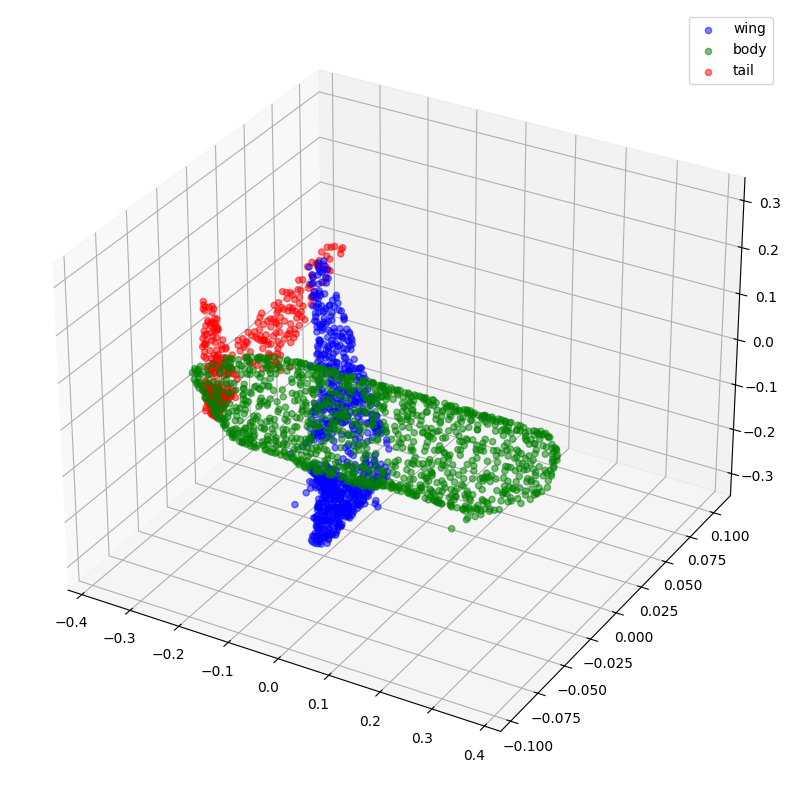

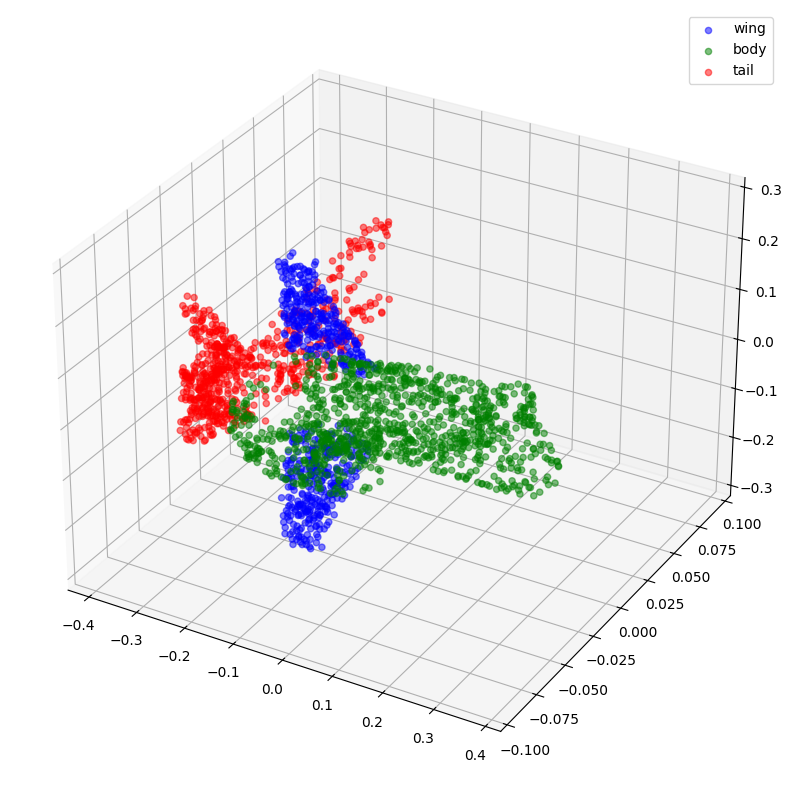

In [ ]:
def visualize_data(point_cloud, labels):
    df = pd.DataFrame(
        data={
            "x": point_cloud[:, 0],
            "y": point_cloud[:, 1],
            "z": point_cloud[:, 2],
            "label": labels,
        }
    )
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection="3d")
    for index, label in enumerate(LABELS):
        c_df = df[df["label"] == label]
        try:
            ax.scatter(
                c_df["x"], c_df["y"], c_df["z"], label=label, alpha=0.5, c=COLORS[index]
            )
        except IndexError:
            pass
    ax.legend()
    plt.show()


visualize_data(point_clouds[0], all_labels[0])
visualize_data(point_clouds[300], all_labels[300])

#Preprocessing

In [ ]:
for index in tqdm(range(len(point_clouds))):
    current_point_cloud = point_clouds[index]
    current_label_cloud = point_cloud_labels[index]
    current_labels = all_labels[index]
    num_points = len(current_point_cloud)


    #randomly sampling respective indices.
    sampled_indices = random.sample(list(range(num_points)), NUM_SAMPLE_POINTS)


    #sampling points corresponding to sampled indices.
    sampled_point_cloud = np.array([current_point_cloud[i] for i in sampled_indices])

    #sampling corresponding one-hot encoded labels.
    sampled_label_cloud = np.array([current_label_cloud[i] for i in sampled_indices])

    #sampling corresponding labels for visualization.
    sampled_labels = np.array([current_labels[i] for i in sampled_indices])

    #normalizing sampled point cloud.
    norm_point_cloud = sampled_point_cloud - np.mean(sampled_point_cloud, axis=0)
    norm_point_cloud /= np.max(np.linalg.norm(norm_point_cloud, axis=1))
    point_clouds[index] = norm_point_cloud
    point_cloud_labels[index] = sampled_label_cloud
    all_labels[index] = sampled_labels

100%|██████████| 3694/3694 [00:08<00:00, 439.86it/s]


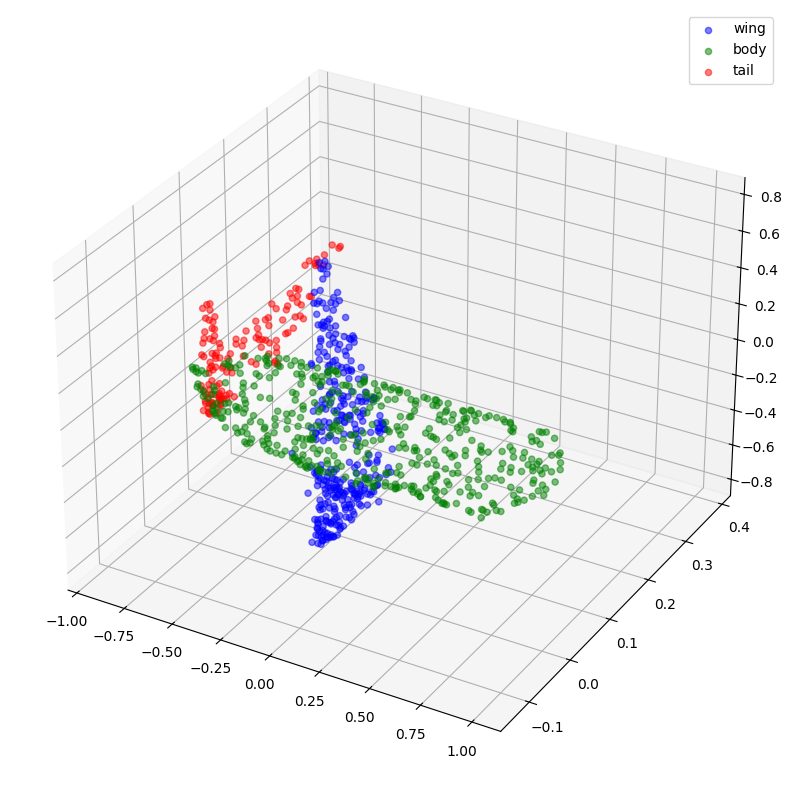

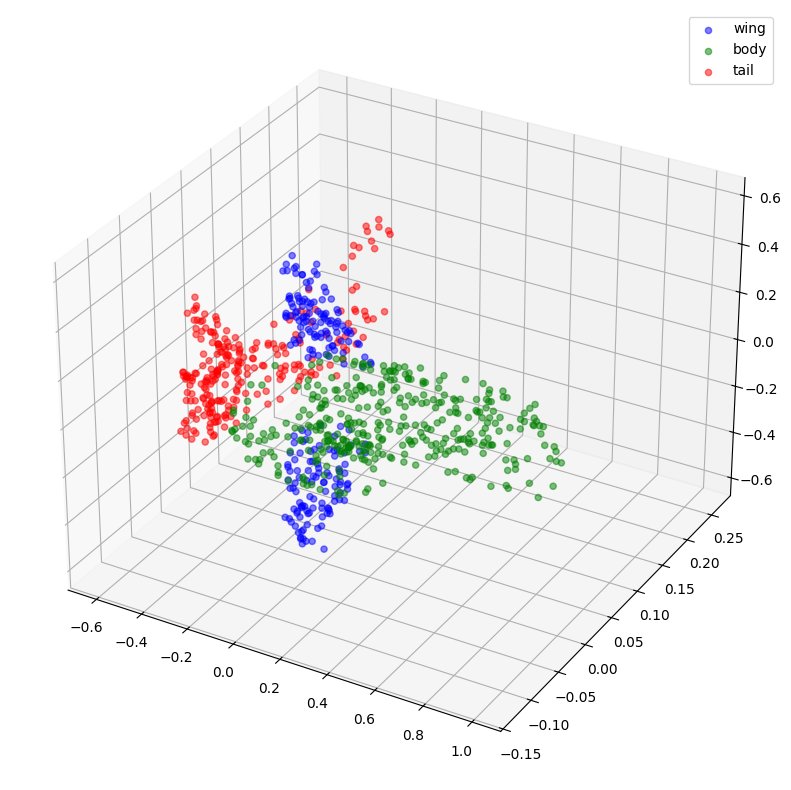

In [ ]:
visualize_data(point_clouds[0], all_labels[0])
visualize_data(point_clouds[300], all_labels[300])

#Creating Tensorflow Datasets

In [ ]:
import numpy as np
import tensorflow as tf

def load_data(point_cloud_batch, label_cloud_batch):
    point_cloud_batch.set_shape([NUM_SAMPLE_POINTS, 3])
    label_cloud_batch.set_shape([NUM_SAMPLE_POINTS, len(LABELS) + 1])
    return point_cloud_batch, label_cloud_batch

def augment(point_cloud_batch, label_cloud_batch):
    noise = tf.random.uniform(
        tf.shape(label_cloud_batch), -0.001, 0.001, dtype=tf.float64
    )
    point_cloud_batch += noise[:, :, :3]
    return point_cloud_batch, label_cloud_batch

def generate_dataset(point_clouds, label_clouds, is_training=True):
    dataset = tf.data.Dataset.from_tensor_slices((point_clouds, label_clouds))
    dataset = dataset.shuffle(BATCH_SIZE * 100) if is_training else dataset
    dataset = dataset.map(load_data, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size=BATCH_SIZE)
    dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE) if is_training else dataset
    return dataset


point_clouds = np.stack(point_clouds)
point_cloud_labels = np.stack(point_cloud_labels)

split_index = int(len(point_clouds) * (1 - VAL_SPLIT))

train_point_clouds = point_clouds[:split_index]
train_label_cloud = point_cloud_labels[:split_index]
total_training_examples = len(train_point_clouds)

val_point_clouds = point_clouds[split_index:]
val_label_cloud = point_cloud_labels[split_index:]

print("Num train point clouds:", len(train_point_clouds))
print("Num train point cloud labels:", len(train_label_cloud))
print("Num val point clouds:", len(val_point_clouds))
print("Num val point cloud labels:", len(val_label_cloud))

train_dataset = generate_dataset(train_point_clouds, train_label_cloud)
val_dataset = generate_dataset(val_point_clouds, val_label_cloud, is_training=False)

print("Train Dataset:", train_dataset)
print("Validation Dataset:", val_dataset)


Num train point clouds: 2955
Num train point cloud labels: 2955
Num val point clouds: 739
Num val point cloud labels: 739
Train Dataset: <_ParallelMapDataset element_spec=(TensorSpec(shape=(None, 1024, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1024, 5), dtype=tf.float64, name=None))>
Validation Dataset: <_BatchDataset element_spec=(TensorSpec(shape=(None, 1024, 3), dtype=tf.float64, name=None), TensorSpec(shape=(None, 1024, 5), dtype=tf.float64, name=None))>


#Pointnet model

In [ ]:
def conv_block(x, filters, name):
    x = layers.Conv1D(filters, kernel_size=1, padding="valid", name=f"{name}_conv")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)


def mlp_block(x, filters, name):
    x = layers.Dense(filters, name=f"{name}_dense")(x)
    x = layers.BatchNormalization(name=f"{name}_batch_norm")(x)
    return layers.Activation("relu", name=f"{name}_relu")(x)

In [ ]:
class OrthogonalRegularizer(keras.regularizers.Regularizer):
    """Reference: https://keras.io/examples/vision/pointnet/#build-a-model"""

    def __init__(self, num_features, l2reg=0.001):
        self.num_features = num_features
        self.l2reg = l2reg
        self.identity = keras.ops.eye(num_features)

    def __call__(self, x):
        x = keras.ops.reshape(x, (-1, self.num_features, self.num_features))
        xxt = keras.ops.tensordot(x, x, axes=(2, 2))
        xxt = keras.ops.reshape(xxt, (-1, self.num_features, self.num_features))
        return keras.ops.sum(self.l2reg * keras.ops.square(xxt - self.identity))

    def get_config(self):
        config = super().get_config()
        config.update({"num_features": self.num_features, "l2reg_strength": self.l2reg})
        return config

In [ ]:
def transformation_net(inputs, num_features, name):
    """
    Reference: https://keras.io/examples/vision/pointnet/#build-a-model.

    The `filters` values come from the original paper:
    https://arxiv.org/abs/1612.00593.
    """
    x = conv_block(inputs, filters=64, name=f"{name}_1")
    x = conv_block(x, filters=128, name=f"{name}_2")
    x = conv_block(x, filters=1024, name=f"{name}_3")
    x = layers.GlobalMaxPooling1D()(x)
    x = mlp_block(x, filters=512, name=f"{name}_1_1")
    x = mlp_block(x, filters=256, name=f"{name}_2_1")
    return layers.Dense(
        num_features * num_features,
        kernel_initializer="zeros",
        bias_initializer=keras.initializers.Constant(np.eye(num_features).flatten()),
        activity_regularizer=OrthogonalRegularizer(num_features),
        name=f"{name}_final",
    )(x)


def transformation_block(inputs, num_features, name):
    transformed_features = transformation_net(inputs, num_features, name=name)
    transformed_features = layers.Reshape((num_features, num_features))(
        transformed_features
    )
    return layers.Dot(axes=(2, 1), name=f"{name}_mm")([inputs, transformed_features])

In [ ]:
def get_shape_segmentation_model(num_points, num_classes):
    input_points = keras.Input(shape=(None, 3))

    #pointNet Classification Network.
    transformed_inputs = transformation_block(
        input_points, num_features=3, name="input_transformation_block"
    )
    features_64 = conv_block(transformed_inputs, filters=64, name="features_64")
    features_128_1 = conv_block(features_64, filters=128, name="features_128_1")
    features_128_2 = conv_block(features_128_1, filters=128, name="features_128_2")
    transformed_features = transformation_block(
        features_128_2, num_features=128, name="transformed_features"
    )
    features_512 = conv_block(transformed_features, filters=512, name="features_512")
    features_2048 = conv_block(features_512, filters=2048, name="pre_maxpool_block")
    global_features = layers.MaxPool1D(pool_size=num_points, name="global_features")(
        features_2048
    )
    global_features = keras.ops.tile(global_features, [1, num_points, 1])

    #segmentation head.
    segmentation_input = layers.Concatenate(name="segmentation_input")(
        [
            features_64,
            features_128_1,
            features_128_2,
            transformed_features,
            features_512,
            global_features,
        ]
    )
    segmentation_features = conv_block(
        segmentation_input, filters=128, name="segmentation_features"
    )
    outputs = layers.Conv1D(
        num_classes, kernel_size=1, activation="softmax", name="segmentation_head"
    )(segmentation_features)
    return keras.Model(input_points, outputs)

#Instaniate model

In [ ]:
x, y = next(iter(train_dataset))

num_points = x.shape[1]
num_classes = y.shape[-1]

segmentation_model = get_shape_segmentation_model(num_points, num_classes)
segmentation_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None, 3)        │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 64)       │            256 │ input_layer[0][0]      │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 64)       │            256 │ input_transformation_… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 64)       │              0 │ input_transformation_… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 128)      │          8,320 │ input_transformation_… │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 128)      │            512 │ input_transformation_… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 128)      │              0 │ input_transformation_… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 1024)     │        132,096 │ input_transformation_… │
│ (Conv1D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 1024)     │          4,096 │ input_transformation_… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, None, 1024)     │              0 │ input_transformation_… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d      │ (None, 1024)           │              0 │ input_transformation_… │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, 512)            │        524,800 │ global_max_pooling1d[… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_blo… │ (None, 512)            │          2,048 │ input_transformation_… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_transformation_

 Total params: 7,370,062 (28.11 MB)

 Trainable params: 7,356,110 (28.06 MB)

 Non-trainable params: 13,952 (54.50 KB)

#Training

In [ ]:
EPOCHS = 90

Steps per epoch: 92.
Total training steps: 8280.


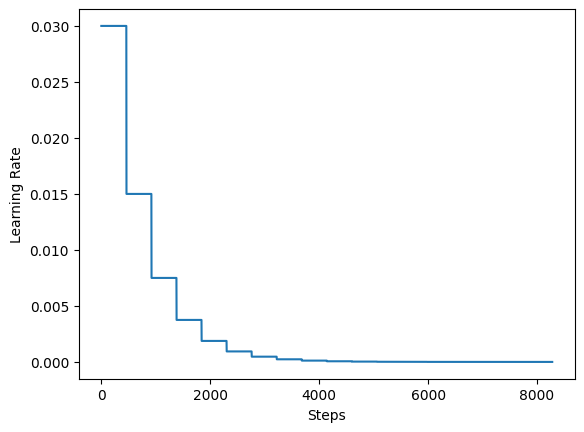

In [ ]:
steps_per_epoch = total_training_examples // BATCH_SIZE
total_training_steps = steps_per_epoch * EPOCHS
print(f"Steps per epoch: {steps_per_epoch}.")
print(f"Total training steps: {total_training_steps}.")

lr_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.03,
    decay_steps=steps_per_epoch * 5,
    decay_rate=0.5,
    staircase=True,
)

steps = range(total_training_steps)
lrs = [lr_schedule(step) for step in steps]

plt.plot(lrs)
plt.xlabel("Steps")
plt.ylabel("Learning Rate")
plt.show()

In [ ]:
models_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/processed_data/models"






import os
import keras

def run_experiment(epochs):
    #get the segmentation model
    segmentation_model = get_shape_segmentation_model(num_points, num_classes)
    segmentation_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
        loss=keras.losses.CategoricalCrossentropy(),
        metrics=["accuracy"],
    )


    os.makedirs(models_dir, exist_ok=True)

    #define checkpoint file path inside "models" folder
    checkpoint_filepath = os.path.join(models_dir, "best_model.weights.h5")

    #save only the best model weights
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    #train
    history = segmentation_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=[checkpoint_callback],
    )

    #load best model weights
    segmentation_model.load_weights(checkpoint_filepath)

    return segmentation_model, history

#run the training process
segmentation_model, history = run_experiment(epochs=EPOCHS)


Epoch 1/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.4182 - loss: 56627012.0000
Epoch 1: val_loss improved from inf to 618652106752.00000, saving model to /content/drive/MyDrive/3D_PointCloud_Seg/processed_data/models/best_model.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 65s 370ms/step - accuracy: 0.4189 - loss: 56198004.0000 - val_accuracy: 0.1419 - val_loss: 618652106752.0000
Epoch 2/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.6640 - loss: 88377.0312
Epoch 2: val_loss improved from 618652106752.00000 to 948708992.00000, saving model to /content/drive/MyDrive/3D_PointCloud_Seg/processed_data/models/best_model.weights.h5
93/93 ━━━━━━━━━━━━━━━━━━━━ 46s 182ms/step - accuracy: 0.6642 - loss: 88149.5234 - val_accuracy: 0.3697 - val_loss: 948708992.0000
Epoch 3/90
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.7085 - loss: 32655.2031
Epoch 3: val_loss improved from 948708992.00000 to 46560700.00000, saving model to /content/drive/MyDrive/3D_PointCloud_Seg/proce

Visualize Training landscape

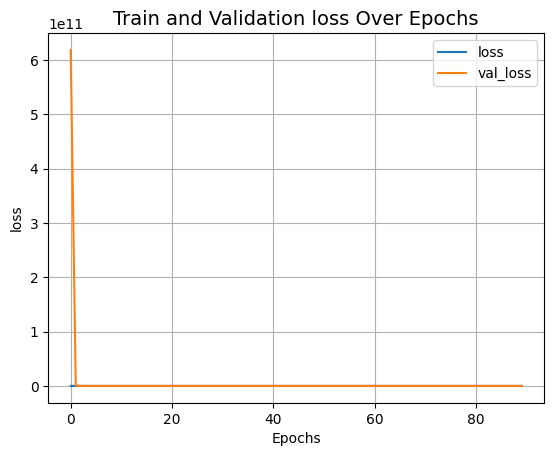

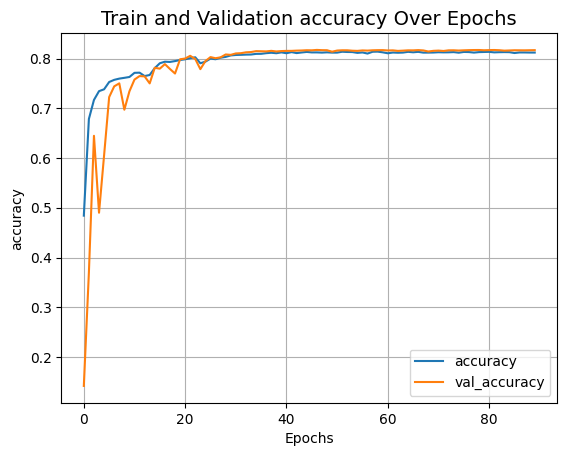

In [ ]:
def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("accuracy")

#Inference

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Validation prediction shape: (32, 1024, 5)
Index selected: 2


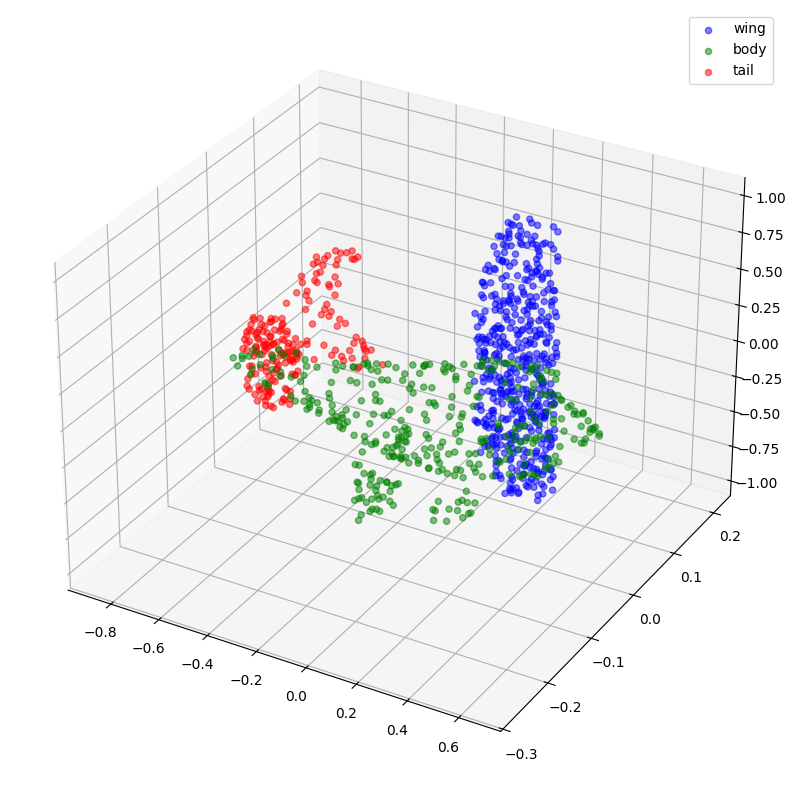

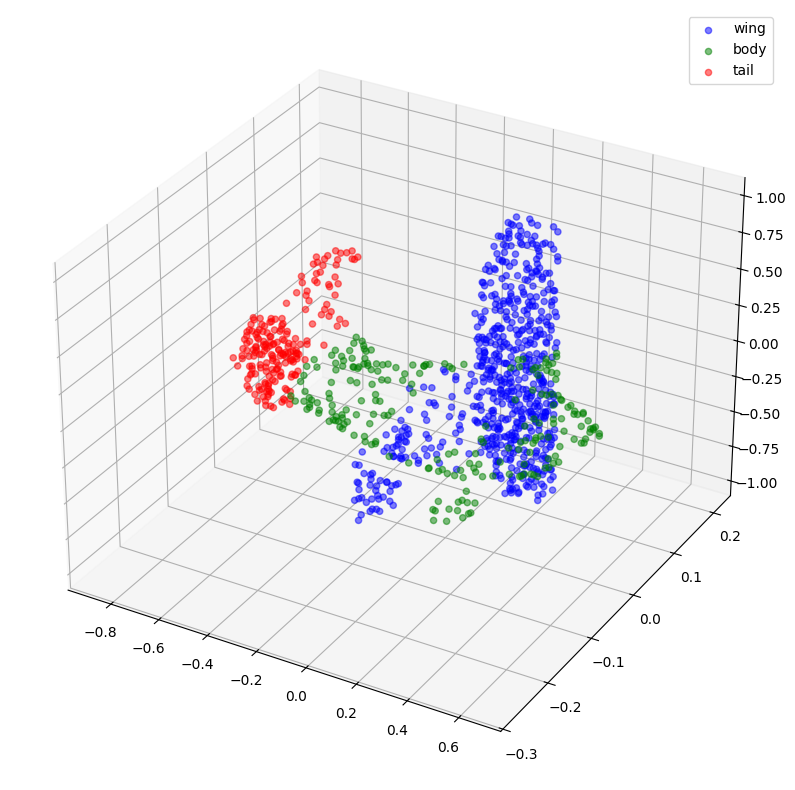

In [ ]:
validation_batch = next(iter(val_dataset))
val_predictions = segmentation_model.predict(validation_batch[0])
print(f"Validation prediction shape: {val_predictions.shape}")


def visualize_single_point_cloud(point_clouds, label_clouds, idx):
    label_map = LABELS + ["none"]
    point_cloud = point_clouds[idx]
    label_cloud = label_clouds[idx]
    visualize_data(point_cloud, [label_map[np.argmax(label)] for label in label_cloud])


idx = np.random.choice(len(validation_batch[0]))
print(f"Index selected: {idx}")

#ground-truth.
visualize_single_point_cloud(validation_batch[0], validation_batch[1], idx)

#predicted labels.
visualize_single_point_cloud(validation_batch[0], val_predictions, idx)

#Test Point Clouds

In [ ]:
import os
import shutil
import glob

processed_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/test_data"
os.makedirs(processed_dir, exist_ok=True)


In [ ]:
for i, point_cloud in enumerate(test_point_clouds):
    save_path = os.path.join(processed_dir, f"test_point_cloud_{i}.pts")
    np.savetxt(save_path, point_cloud, fmt="%.6f")

print(f"Saved {len(test_point_clouds)} test point clouds to {processed_dir}")


NameError: name 'test_point_clouds' is not defined

#Damage Assessment


In [ ]:
!pip install tqdm


In [ ]:
import open3d as o3d
from pathlib import Path

In [ ]:
def normalize_pd(pd):
    births = pd[:, 0]
    deaths = pd[:, 1]
    orders = pd[:, 2]

    #replace infinity with a large finite value
    finite_deaths = np.where(
        deaths == np.inf, np.max(deaths[np.isfinite(deaths)]) * 1.1, deaths
    )

    #min and max values
    min_val = min(np.min(births), np.min(finite_deaths))
    max_val = max(np.max(births), np.max(finite_deaths))

    normalized_births = (births - min_val) / (max_val - min_val)
    normalized_deaths = (finite_deaths - min_val) / (max_val - min_val)

    #handle the points that had infinity death times
    normalized_deaths[deaths == np.inf] = 1.1

    normalized_pd = np.column_stack((normalized_births, normalized_deaths, orders))

    #format back into original nested list structure
    formatted_normalized_pd = np.array(
        [[[item[0], item[1], item[2]] for item in normalized_pd]]
    )

    return formatted_normalized_pd


def alphacomplex(X, normalize=True):
    ac = gudhi.AlphaComplex(points=X)
    st = ac.create_simplex_tree()
    #pers = st.persistence(min_persistence=0.0001)
    pd = np.array(
        [
            [val[1][0], val[1][1], val[0]]
            for val in st.persistence(persistence_dim_max=True)
        ]
    )
    if normalize:
        pd = normalize_pd(pd)
    else:
        pd = np.expand_dims(pd, axis=0)
    return pd


#maybe we should use this...
def pcdfile2pts(file):
    pt = Path(file)
    if pt.suffix in [".ply", ".pcd"]:
        pcd = o3d.io.read_point_cloud(file)
        pts = np.asarray(pcd.points)
    elif pt.suffix in [".laz", ".las"]:
        with laspy.open(file) as f:
            wlas = f.read()
        pts = np.column_stack((np.array(wlas.x), np.array(wlas.y), np.array(wlas.z)))

    return pts



def pts2tda(pts):
    diags = alphacomplex(pts)
    amp = [
        "bottleneck",
        "wasserstein",
        "betti",
        "heat",
        "landscape",
        "silhouette",
        "persistence_image",
    ]
    ops = [PSE, NOP]
    feat_v = np.zeros(6 + 3 * len(amp))
    for jx in range(2 + len(amp)):
        if jx < 2:
            mea = ops[jx]()
        else:
            mea = APT(metric=amp[jx - 2])
        feature = mea.fit_transform(diags)
        print(feature)
        feat_v[3 * jx : (3 * jx + 3)] = np.array(feature[0])
    return feat_v

In [ ]:
import os
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
import joblib



#extract Features from Parts
# ----------------------------
'''
def extract_features(points):

    if len(points) == 0:
        return np.zeros(7)

    centroid = np.mean(points, axis=0)
    bbox_size = np.ptp(points, axis=0)
    point_density = len(points) / (np.linalg.norm(bbox_size) + 1e-6)

    return np.concatenate([centroid, bbox_size, [point_density]])
'''

def extract_features(points):
    """
    Extract topological features from a point cloud using TDA.

    Parameters:
        points (np.ndarray): Nx3 array of 3D point coordinates.

    Returns:
        np.ndarray: Flattened feature vector of TDA features.
    """
    if len(points) == 0:
        # Handle empty point clouds gracefully
        return np.zeros(6 + 3 * 7)

    try:

        feat_v = pts2tda(points)

        print("Feature Vector: ", feat_v.shape )


    except Exception as e:
        print(f"TDA feature extraction failed: {e}")
        feat_v = np.zeros(6 + 3 * 7)

    return feat_v


#train models
# ----------------------------
def train_isolation_forest_models(train_pcs, train_labels):

    part_names = ['wing', 'body', 'tail', 'engine']
    part_models = {}

    for i, part in enumerate(part_names):

        print(f"Training model for {part}...")

        features = [extract_features(pc[labels == i])
                    for pc, labels in zip(train_pcs, train_labels)]

        model = IsolationForest()
        model.fit(features)

        part_models[part] = model
        joblib.dump(model, f"/content/drive/MyDrive/3D_PointCloud_Seg/Damage_Assessment/TDA_STRS/{part}_STR_model.joblib")

    return part_models


#predict damage on new sample
# ----------------------------

def predict_damage(point_cloud, labels, part_models):
    results = {}
    part_names = ['wing', 'body', 'tail', 'engine']

    for i, part in enumerate(part_names):
        part_points = point_cloud[labels == i]
        features = extract_features(part_points).reshape(1, -1)
        model = part_models[part]

        score = model.decision_function(features)[0]
        is_anomalous = model.predict(features)[0] == -1

        results[part] = {
            "status": "damaged" if is_anomalous else "healthy",
            "score": score
        }

    return results


In [ ]:

points_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points"
labels_dir = "/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/PartAnnotation/02691156/points_label"

part_map = {'body': 0, 'engine': 1, 'tail': 2, 'wing': 3}
part_names = list(part_map.keys())


In [ ]:
'''pts_files = [f for f in os.listdir(points_dir) if f.endswith(".pts")]
point_clouds = []
part_labels_list = []'''

KeyboardInterrupt: 

In [ ]:
import os
import numpy as np
from multiprocessing import Pool, cpu_count, set_start_method
from tqdm.notebook import tqdm

'''
def initializer(tqdm_lock_):
    global tqdm_lock
    tqdm_lock = tqdm_lock_

def process_file(fname):
    base_name = os.path.splitext(fname)[0]
    pts_txt_path = os.path.join(points_dir, fname)
    pts_npy_path = pts_txt_path.replace('.pts', '.npy')

    #convert .pts to .npy
    if not os.path.exists(pts_npy_path):
        pc = np.loadtxt(pts_txt_path)
        np.save(pts_npy_path, pc)
    else:
        pc = np.load(pts_npy_path)

    labels = np.full(pc.shape[0], -1)

    for part, idx in part_map.items():
        seg_txt_path = os.path.join(labels_dir, part, f"{base_name}.seg")
        seg_npy_path = seg_txt_path.replace('.seg', '.npy')

        if os.path.exists(seg_txt_path) and not os.path.exists(seg_npy_path):
            seg = np.loadtxt(seg_txt_path).astype(bool)
            np.save(seg_npy_path, seg)
        elif os.path.exists(seg_npy_path):
            seg = np.load(seg_npy_path)
        else:
            continue

        labels[seg] = idx

    return pc, labels

#multiprocessing with progress bar
if __name__ == '__main__':
    set_start_method("fork", force=True)
    from multiprocessing import Manager

    with Manager() as manager:

        tqdm_lock = manager.Lock()


        with Pool(processes=cpu_count(), initializer=initializer, initargs=(tqdm_lock,)) as pool:
            results = list(tqdm(pool.imap(process_file, pts_files), total=len(pts_files)))

    point_clouds, part_labels_list = zip(*results)
    '''


'\ndef initializer(tqdm_lock_):\n    global tqdm_lock\n    tqdm_lock = tqdm_lock_\n\ndef process_file(fname):\n    base_name = os.path.splitext(fname)[0]\n    pts_txt_path = os.path.join(points_dir, fname)\n    pts_npy_path = pts_txt_path.replace(\'.pts\', \'.npy\')\n\n    #convert .pts to .npy\n    if not os.path.exists(pts_npy_path):\n        pc = np.loadtxt(pts_txt_path)\n        np.save(pts_npy_path, pc)\n    else:\n        pc = np.load(pts_npy_path)\n\n    labels = np.full(pc.shape[0], -1)\n\n    for part, idx in part_map.items():\n        seg_txt_path = os.path.join(labels_dir, part, f"{base_name}.seg")\n        seg_npy_path = seg_txt_path.replace(\'.seg\', \'.npy\')\n\n        if os.path.exists(seg_txt_path) and not os.path.exists(seg_npy_path):\n            seg = np.loadtxt(seg_txt_path).astype(bool)\n            np.save(seg_npy_path, seg)\n        elif os.path.exists(seg_npy_path):\n            seg = np.load(seg_npy_path)\n        else:\n            continue\n\n        labels[

In [ ]:
#save to .npy for future fast reuse
#np.save('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/point_clouds.npy', np.array(point_clouds, dtype=object), allow_pickle=True)
#np.save('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/part_labels_list.npy', np.array(part_labels_list, dtype=object), allow_pickle=True)


In [ ]:
import numpy as np

#load the cached data
point_clouds = np.load('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/point_clouds.npy', allow_pickle=True)
part_labels_list = np.load('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/part_labels_list.npy', allow_pickle=True)

#example point cloud
first_point_cloud = point_clouds[0]
first_part_labels = part_labels_list[0]

print("First point cloud shape:", first_point_cloud.shape)
print("First label array shape:", first_part_labels.shape)


First point cloud shape: (2401, 3)
First label array shape: (2401,)


In [ ]:

print(point_clouds)

[array([[ 0.10598, -0.01978, -0.02555],
        [-0.17637, -0.02053,  0.0257 ],
        [-0.25861, -0.00769, -0.01584],
        ...,
        [-0.10129, -0.0472 ,  0.17685],
        [-0.08205, -0.04828,  0.15243],
        [-0.03477, -0.04212, -0.09811]])
 array([[-0.30633,  0.04931, -0.00036],
        [ 0.07764, -0.04995,  0.11343],
        [-0.18982, -0.0268 ,  0.02563],
        ...,
        [ 0.30187, -0.05797,  0.01792],
        [ 0.03819, -0.05018,  0.10799],
        [-0.28499,  0.01367,  0.00245]])
 array([[ 0.32601, -0.04317, -0.02108],
        [ 0.24344, -0.05723,  0.01426],
        [ 0.09661, -0.02365,  0.02505],
        ...,
        [-0.09306, -0.02173,  0.29317],
        [-0.23414, -0.04473, -0.02238],
        [ 0.04987, -0.05873,  0.02092]]) ...
 array([[ 0.11014, -0.02037,  0.00838],
        [ 0.28089,  0.01576,  0.02704],
        [ 0.12111, -0.01659,  0.01416],
        ...,
        [-0.12312,  0.03682,  0.02688],
        [-0.24917,  0.03398,  0.0234 ],
        [-0.09439,  0

In [ ]:

'''

Basic Random Sampling

- in this technique, points are randomly sampled from the overall pool of points within the point cloud
'''
'''
def rs_pointcloud(points,labels,num_samples=1024):

  idx = np.random.choice(points.shape[0],num_samples,replace=False)

  return points[idx],labels[idx]

'''


'''
Stratified Random Sampling

- this technique uses the same random sampling concept, but takes into account class labels when sampling points
- for instance, the same number of points in the wing class will be sampled as the body or tail classes
'''

'''
def str_rs_pcd(points, labels, total_samples=1024):
    unique_labels, counts = np.unique(labels, return_counts=True)
    proportions = counts / counts.sum()

    sampled_indices = []

    for ul, prop in zip(unique_labels, proportions):
        class_indices = np.where(labels == ul)[0]

        n_samples = max(1, int(total_samples * prop))
        n_samples = min(n_samples, len(class_indices))

        sampled_idx = np.random.choice(class_indices, size=n_samples, replace=False)
        sampled_indices.append(sampled_idx)

    sampled_indices = np.concatenate(sampled_indices)

    #adjust final size to exactly total_samples
    if len(sampled_indices) > total_samples:
        sampled_indices = np.random.choice(sampled_indices, total_samples, replace=False)
    elif len(sampled_indices) < total_samples:
        #randomly duplicate points if too few
        extra = np.random.choice(sampled_indices, total_samples - len(sampled_indices), replace=True)
        sampled_indices = np.concatenate([sampled_indices, extra])

    return points[sampled_indices], labels[sampled_indices]
'''

'''
Farthest Point Sampling

- this technique is used in practice when dealing with Point Cloud data, it uses a min max algorithm that aims to sample the farthest points away from a group of sampled points
- this method is perferred over randome sampling techniques as it preserves the geometric characteristics and distribution from the original point cloud

'''

import numpy as np

def fps_pcd(points, labels, num_samples=1024):

    N = points.shape[0]
    num_samples = min(num_samples, N)

    sampled_idx = np.zeros(num_samples, dtype=np.int64)

    #start from a random point
    sampled_idx[0] = np.random.randint(0, N)

    #distance to nearest selected point
    dist = np.full(N, np.inf)

    for i in range(1, num_samples):
        last = points[sampled_idx[i-1]]

        #compute squared distances to last chosen point
        d = np.sum((points - last) ** 2, axis=1)

        #update min distance to set
        dist = np.minimum(dist, d)

        #choose farthest point
        sampled_idx[i] = np.argmax(dist)

    return points[sampled_idx], labels[sampled_idx]



point_clouds_RS = []
point_labels_RS = []



for pc, lbl, in zip(point_clouds, part_labels_list):

  pc_s, lbl_s = fps_pcd(pc, lbl)

  point_clouds_RS.append(pc_s)
  point_labels_RS.append(lbl_s)



In [ ]:
print(len(point_clouds_RS[0]))
print(len(point_labels_RS[0]))


1024
1024


In [ ]:
#split data i
train_pcs, test_pcs, train_labels, test_labels = train_test_split(
    point_clouds_RS, point_labels_RS, test_size=0.2, random_state=42)


In [ ]:
train_pcs = np.array(train_pcs, dtype=object)
train_labels = np.array(train_labels, dtype=object)

test_pcs = np.array(test_pcs, dtype=object)
test_labels = np.array(test_labels, dtype=object)


In [ ]:
print(train_pcs.shape)
print(train_labels.shape)

print(test_pcs.shape)
print(test_labels.shape)

(3236, 1024, 3)
(3236, 1024)
(809, 1024, 3)
(809, 1024)


In [ ]:

#train isolation forest models on data for each part
part_models = train_isolation_forest_models(train_pcs, train_labels)



Streaming output truncated to the last 5000 lines.
[[6.97791102 6.5625678  5.3087133 ]]
[[335 457 117]]
[[0.55       0.22422569 0.00458474]]
[[0.60206212 0.25065291 0.00947373]]
[[39.54968745  7.28325901  0.44851753]]
[[28.68048613 27.77300401  0.62474494]]
[[0.33302455 0.08706128 0.00041772]]
[[6.39508103e-02 1.61143546e-02 4.01397897e-05]]
[[507.93671044 759.61632389  55.58216721]]
Feature Vector:  (27,)
[[7.92955879 6.87622154 4.80708536]]
[[349 413  65]]
[[0.55       0.28408955 0.00977349]]
[[0.99970007 0.76793181 0.0185932 ]]
[[74.55266595 16.62238782  0.51394979]]
[[274.04091429 157.25339214   2.63815643]]
[[0.33302455 0.1528584  0.00115842]]
[[0.01885376 0.0260006  0.00012494]]
[[585.51157254 662.47559949  40.57052458]]
Feature Vector:  (27,)
[[7.27758578 6.64925986 4.18555837]]
[[291 290  49]]
[[0.55      0.0542905 0.004384 ]]
[[0.63804911 0.18580358 0.00598038]]
[[42.15118293  6.39908017  0.19691051]]
[[74.08447508 52.38611686  0.41782909]]
[[3.33024548e-01 1.96225341e-02 2.63

In [ ]:
print(test_labels)

[array([0, 1, 1, ..., 0, 0, 3]) array([0, 1, 0, ..., 0, 0, 0])
 array([1, 0, 0, ..., 0, 0, 0]) array([0, 0, 0, ..., 2, 1, 0])
 array([1, 0, 0, ..., 0, 0, 0]) array([0, 3, 3, ..., 0, 0, 0])
 array([0, 0, 0, ..., 0, 0, 3]) array([-1, -1, -1, ...,  3,  3,  3])
 array([0, 1, 0, ..., 3, 0, 0]) array([ 0, -1, -1, ..., -1, -1, -1])
 array([ 0,  0, -1, ..., -1, -1, -1]) array([0, 2, 1, ..., 3, 0, 3])
 array([2, 3, 0, ..., 1, 3, 0]) array([2, 0, 1, ..., 0, 0, 0])
 array([-1, -1, -1, ...,  0,  0,  0]) array([ 0,  0,  0, ...,  2, -1, -1])
 array([0, 1, 0, ..., 0, 0, 3]) array([2, 3, 0, ..., 3, 3, 0])
 array([0, 0, 0, ..., 0, 3, 2]) array([3, 3, 0, ..., 0, 3, 1])
 array([0, 1, 0, ..., 0, 0, 0]) array([0, 0, 3, ..., 3, 3, 3])
 array([0, 3, 0, ..., 3, 3, 0]) array([3, 3, 3, ..., 0, 0, 0])
 array([0, 0, 0, ..., 3, 0, 0]) array([0, 2, 3, ..., 3, 2, 3])
 array([1, 3, 2, ..., 0, 0, 3]) array([3, 3, 0, ..., 0, 3, 0])
 array([0, 3, 3, ..., 0, 0, 3]) array([0, 0, 0, ..., 3, 3, 3])
 array([1, 0, 1, ..., 3, 

In [ ]:
#evaluate on test set
print("\nEvaluation on test set:")
for idx, (pc, labels) in enumerate(zip(test_pcs, test_labels)):
    report = predict_damage(pc, labels, part_models)
    print(f"\nTest Sample {idx + 1}:")
    for part, status in report.items():
        print(f"  {part.capitalize()}: {status}")


Streaming output truncated to the last 5000 lines.
[[45.87780064 53.35862437  1.4585402 ]]
Feature Vector:  (27,)
[[8.86149139 9.36599452 7.98923075]]
[[ 614 1468  541]]
[[0.55       0.04740852 0.00942357]]
[[0.60217651 0.20441001 0.0208411 ]]
[[92.7864334  37.33263754  2.26155996]]
[[86.59514673 97.96694033  3.28111973]]
[[0.33302455 0.01115665 0.0009265 ]]
[[2.82918693e-02 8.13934123e-04 3.51485232e-05]]
[[ 920.62188341 2132.99914078  357.71335459]]
Feature Vector:  (27,)
[[8.71422623 8.10800565 4.17041197]]
[[511 722 138]]
[[0.55       0.15183137 0.25643033]]
[[0.68885306 0.55940544 0.26702383]]
[[93.55236205 39.12540324  3.42054737]]
[[169.59830854 246.5795666   15.6513942 ]]
[[0.33302455 0.05033647 0.10603267]]
[[0.0195931  0.00684373 0.0420329 ]]
[[ 801.06511785 1263.05940949  197.03217269]]
Feature Vector:  (27,)
[[5.10072108 6.23577593 4.64197405]]
[[104 148  46]]
[[0.55       0.0365782  0.00407635]]
[[0.97389265 0.07963672 0.00780883]]
[[18.71600622  4.21838783  0.3890467 ]]
[

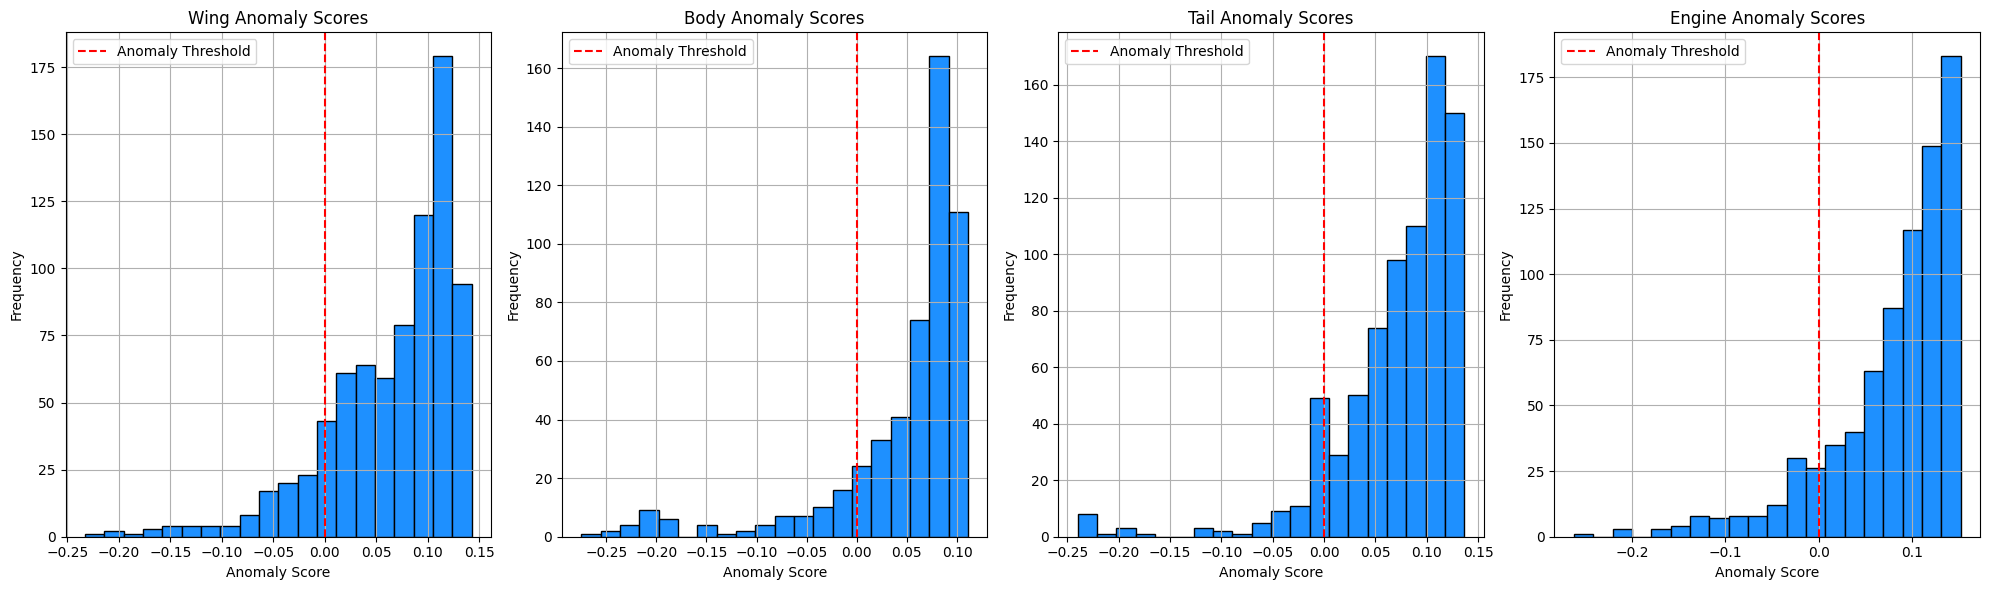

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


part_to_label = {
    "wing": 0,
    "body": 1,
    "tail": 2,
    "engine": 3
}


label_to_part = {v: k for k, v in part_to_label.items()}


anomaly_scores = {part: [] for part in part_to_label}

for pc, labels in zip(test_pcs, test_labels):
    for part, label in part_to_label.items():
        part_points = pc[labels == label]
        if part_points.shape[0] > 0:
            features = extract_features(part_points).reshape(1, -1)
            score = part_models[part].decision_function(features)[0]
            anomaly_scores[part].append(score)


plt.figure(figsize=(20, 6))
for i, (part, scores) in enumerate(anomaly_scores.items(), 1):
    plt.subplot(1, 4, i)
    plt.hist(scores, bins=20, color='dodgerblue', edgecolor='black')
    plt.title(f"{part.capitalize()} Anomaly Scores")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold')
    plt.legend()

    plt.grid(True)

plt.tight_layout()
plt.show()




In [ ]:
def swap_wing_engine_labels(sample_labels, part_to_label):
    """
    Swap wing and engine labels in a label array.
    """
    wing_label = part_to_label['wing']
    engine_label = part_to_label['engine']

    # Make a copy to avoid modifying original
    labels_fixed = sample_labels.copy()

    # Swap labels
    labels_fixed[sample_labels == wing_label] = -1  # temporary marker
    labels_fixed[sample_labels == engine_label] = wing_label
    labels_fixed[labels_fixed == -1] = engine_label

    return labels_fixed


In [ ]:
import plotly.graph_objects as go
import numpy as np

# Select the specific sample
sample_idx = 25
sample_pc = test_pcs[sample_idx]
sample_labels = test_labels[sample_idx]
sample_labels = swap_wing_engine_labels(sample_labels, part_to_label)

# Parts and colors
part_colors = {
    "wing": "blue",
    "body": "blue",
    "tail": "red",
    "engine": "green"
}

fig = go.Figure()

for part, color in part_colors.items():
    label = part_to_label[part]
    mask = (sample_labels == label)
    part_points = sample_pc[mask]

    if part_points.shape[0] == 0:
        continue

    # Compute anomaly score
    features = extract_features(part_points).reshape(1, -1)
    score = part_models[part].decision_function(features)[0]

    fig.add_trace(
        go.Scatter3d(
            x=part_points[:,0],
            y=part_points[:,1],
            z=part_points[:,2],
            mode='markers',
            marker=dict(size=3, color=color),
            name=f"{part} (Anomaly score (Damage): {score:.2f})",
            showlegend=(part != "engine")  # hide engine from legend
        )
    )

fig.update_layout(
    template='plotly_dark',
    height=600,
    width=800,
    title_text=f"3D Point Cloud Damage Assessment",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    )
)

fig.show()


[[7.85108484 7.88992019 6.00700138]]
[[295 501 166]]
[[0.55       0.08141881 0.02392462]]
[[0.81771369 0.341528   0.04421034]]
[[65.83540081 20.63461393  1.32471087]]
[[178.65426768 140.46026398  11.18403011]]
[[0.33302455 0.03335593 0.00408577]]
[[0.02430287 0.00277802 0.00039148]]
[[467.66321459 870.35535709 200.91517047]]
Feature Vector:  (27,)
[[2.62896715 5.90793315 2.33621889]]
[[ 81 145  36]]
[[0.55       0.01121224 0.01192471]]
[[0.70944236 0.0226858  0.01555511]]
[[8.75531585 1.56990421 0.35648162]]
[[4.26306804 1.94201713 0.78407622]]
[[0.33302455 0.00116577 0.00113017]]
[[2.36230851e-01 1.74512644e-04 7.71018421e-04]]
[[117.84222403 104.24853682  27.04996564]]
Feature Vector:  (27,)
[[6.44187396 6.05828899 3.44697812]]
[[102 140  26]]
[[0.55       0.14395101 0.0289065 ]]
[[0.88462122 0.3971109  0.03340266]]
[[33.51517069  7.6840915   0.47002098]]
[[161.36574101  71.77918843   3.03786397]]
[[0.33302455 0.07304907 0.0040951 ]]
[[0.03087938 0.0079359  0.00134498]]
[[173.8393239

In [ ]:
import plotly.graph_objects as go
import numpy as np

def demo_damage_prediction(sample_idx, test_pcs, test_labels,
                           part_colors, part_to_label, part_models, extract_features):
    """
    Predict damage/anomaly scores on a sample point cloud and visualize it.
    Legend shows both part name and damage score with correct color.
    """
    sample_pc = test_pcs[sample_idx]
    sample_labels = test_labels[sample_idx]
    sample_labels = swap_wing_engine_labels(sample_labels, part_to_label)

    print(len(sample_pc))
    fig = go.Figure()

    plot_order = ['body', 'wing', 'tail', 'engine']

    for part in plot_order:
        color = part_colors[part]
        label = part_to_label[part]
        mask = (sample_labels == label)
        part_points = sample_pc[mask]

        if part_points.shape[0] == 0:
            continue

        #compute anomaly score
        try:
            features = extract_features(part_points).reshape(1, -1)
            score = part_models[part].decision_function(features)[0]
        except:
            score = float('nan')

        #add a dummy invisible trace for legend with the correct color
        fig.add_trace(
            go.Scatter3d(
                x=[None], y=[None], z=[None],   # no points
                mode='markers',
                marker=dict(size=6, color=color),
                name=f"{part} (Anomaly score (Lower = Anomaly): {score:.2f})",
                showlegend=True
            )
        )

        #plot actual points without adding extra legend
        fig.add_trace(
            go.Scatter3d(
                x=part_points[:,0],
                y=part_points[:,1],
                z=part_points[:,2],
                mode='markers',
                marker=dict(size=3, color=color),
                name=part,  # does not show in legend
                showlegend=False
            )
        )

    fig.update_layout(
        template='plotly_dark',
        height=600,
        width=800,
        title_text=f"3D Point Cloud Damage Assessment",
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z',
            aspectmode='data'
        )
    )

    fig.show()
    return fig


In [ ]:
import numpy as np
'''
def remove_wing_clusters(sample_idx, test_pcs, test_labels, part_to_label, removal_fraction=0.2, random_state=None):
    """
    Make a copy of a sample, remove a fraction of points from both body and engine,
    and return the modified sample.
    Returns:
        modified_pc, modified_labels (np.array, np.array): The modified sample.
    """
    if random_state is not None:
        np.random.seed(random_state)


    modified_pc = test_pcs[sample_idx].copy()
    modified_labels = test_labels[sample_idx].copy()


    parts = ['wing']

    keep_mask = np.ones(len(modified_pc), dtype=bool)

    for part in parts:
        label = part_to_label[part]
        indices = np.where(modified_labels == label)[0]

        if len(indices) == 0:
            print(f"No {part} points found in this sample.")
            continue

        num_remove = max(1, int(len(indices) * removal_fraction))
        remove_indices = np.random.choice(indices, size=num_remove, replace=False)
        keep_mask[remove_indices] = False

    # Apply mask
    modified_pc = modified_pc[keep_mask]
    modified_labels = modified_labels[keep_mask]

    return modified_pc, modified_labels
'''


import numpy as np

def remove_selected_clusters(
    sample_idx,
    test_pcs,
    test_labels,
    part_to_label,
    removal_fraction=0.2,
    random_state=None
):
    """
    Make a copy of a sample and remove a fraction of points
    from the body, wing, and tail parts.

    Args:
        sample_idx (int): Index of the sample to modify.
        test_pcs (np.ndarray): Array of point clouds (N_samples, N_points, 3).
        test_labels (np.ndarray): Corresponding labels (N_samples, N_points).
        part_to_label (dict): Mapping from part name to label value.
        removal_fraction (float): Fraction of points to remove for each part.
        random_state (int or None): Seed for reproducibility.

    Returns:
        (modified_pc, modified_labels) as np.ndarray, np.ndarray
    """
    if random_state is not None:
        np.random.seed(random_state)

    modified_pc = test_pcs[sample_idx].copy()
    modified_labels = test_labels[sample_idx].copy()

    # Remove points from these parts
    parts_to_remove = ['wing']
    keep_mask = np.ones(len(modified_pc), dtype=bool)

    for part in parts_to_remove:
        label = part_to_label[part]
        indices = np.where(modified_labels == label)[0]

        if len(indices) == 0:
            print(f"No {part} points found in this sample.")
            continue

        num_remove = max(1, int(len(indices) * removal_fraction))
        remove_indices = np.random.choice(indices, size=num_remove, replace=False)
        keep_mask[remove_indices] = False

    # Apply mask
    modified_pc = modified_pc[keep_mask]
    modified_labels = modified_labels[keep_mask]

    return modified_pc, modified_labels


In [ ]:
#convert to list if necessary
test_pcs = list(test_pcs) if isinstance(test_pcs, np.ndarray) else test_pcs
test_labels = list(test_labels) if isinstance(test_labels, np.ndarray) else test_labels

#remove 20% of wing points from sample 20
modified_pc, modified_labels = remove_selected_clusters(
    sample_idx=35,
    test_pcs=test_pcs,
    test_labels=test_labels,
    part_to_label=part_to_label,
    removal_fraction=0.97,
    random_state=45
)

#append to dataset
test_pcs.append(modified_pc)
test_labels.append(modified_labels)

print(f"Original sample points: {test_pcs[20].shape[0]}")
print(f"Modified sample points: {modified_pc.shape[0]}")




NameError: name 'test_pcs' is not defined

In [ ]:
import os
import numpy as np

save_dir = "/content/modified_pointclouds"
os.makedirs(save_dir, exist_ok=True)

pc_path = os.path.join(save_dir, "sample35_modified_pc.npy")
labels_path = os.path.join(save_dir, "sample35_modified_labels.npy")

np.save(pc_path, modified_pc)
np.save(labels_path, modified_labels)

print("Saved files to:")
print(pc_path)
print(labels_path)


In [ ]:

modified_sample_idx = len(test_pcs) - 1

demo_damage_prediction(
    sample_idx=modified_sample_idx,
    test_pcs=test_pcs,
    test_labels=test_labels,
    part_colors=part_colors,
    part_to_label=part_to_label,
    part_models=part_models,
    extract_features=extract_features
)


1398


#SVM

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
import joblib


# --- Part label mapping ---
part_to_label = {
    "wing": 0,
    "body": 1,
    "tail": 2,
    "engine": 3
}
label_to_part = {v: k for k, v in part_to_label.items()}


# --- Feature extraction ---
def extract_features(points):
    if len(points) == 0:
        return np.zeros(7)

    centroid = np.mean(points, axis=0)
    bbox_size = np.ptp(points, axis=0)
    point_density = len(points) / (np.linalg.norm(bbox_size) + 1e-6)

    return np.concatenate([centroid, bbox_size, [point_density]])


# --- Train One-Class SVM models ---
def train_one_class_svm_models(train_pcs, train_labels):
    part_models = {}

    for part, label in part_to_label.items():
        print(f"Training One-Class SVM for {part}...")
        features = [extract_features(pc[labels == label]) for pc, labels in zip(train_pcs, train_labels)]
        features = np.array(features)

        model = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
        model.fit(features)

        part_models[part] = model
        joblib.dump(model, f"/content/drive/MyDrive/3D_PointCloud_Seg/Damage_Assessment/one_class_svm_models/{part}_ocsvm_model.joblib")

    return part_models


# --- Predict part damage from point cloud ---
def predict_damage(point_cloud, labels, part_models):
    results = {}
    for part, label in part_to_label.items():
        part_points = point_cloud[labels == label]
        features = extract_features(part_points).reshape(1, -1)
        model = part_models[part]

        score = model.decision_function(features)[0]
        is_anomalous = model.predict(features)[0] == -1

        results[part] = {
            "status": "damaged" if is_anomalous else "healthy",
            "score": score
        }
    return results




In [ ]:
# --- Load dataset ---
point_clouds = np.load('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/point_clouds.npy', allow_pickle=True)
part_labels_list = np.load('/content/drive/MyDrive/3D_PointCloud_Seg/shapenet_extracted/cached/part_labels_list.npy', allow_pickle=True)



In [ ]:

train_pcs, test_pcs, train_labels, test_labels = train_test_split(
    point_clouds, part_labels_list, test_size=0.2, random_state=42)


part_models = train_one_class_svm_models(train_pcs, train_labels)




Training One-Class SVM for wing...
Training One-Class SVM for body...
Training One-Class SVM for tail...
Training One-Class SVM for engine...


Number of files containing each part:

Training Set:
Wing: 3151
Body: 2062
Tail: 3109
Engine: 3117

Test Set:
Wing: 785
Body: 528
Tail: 768
Engine: 789


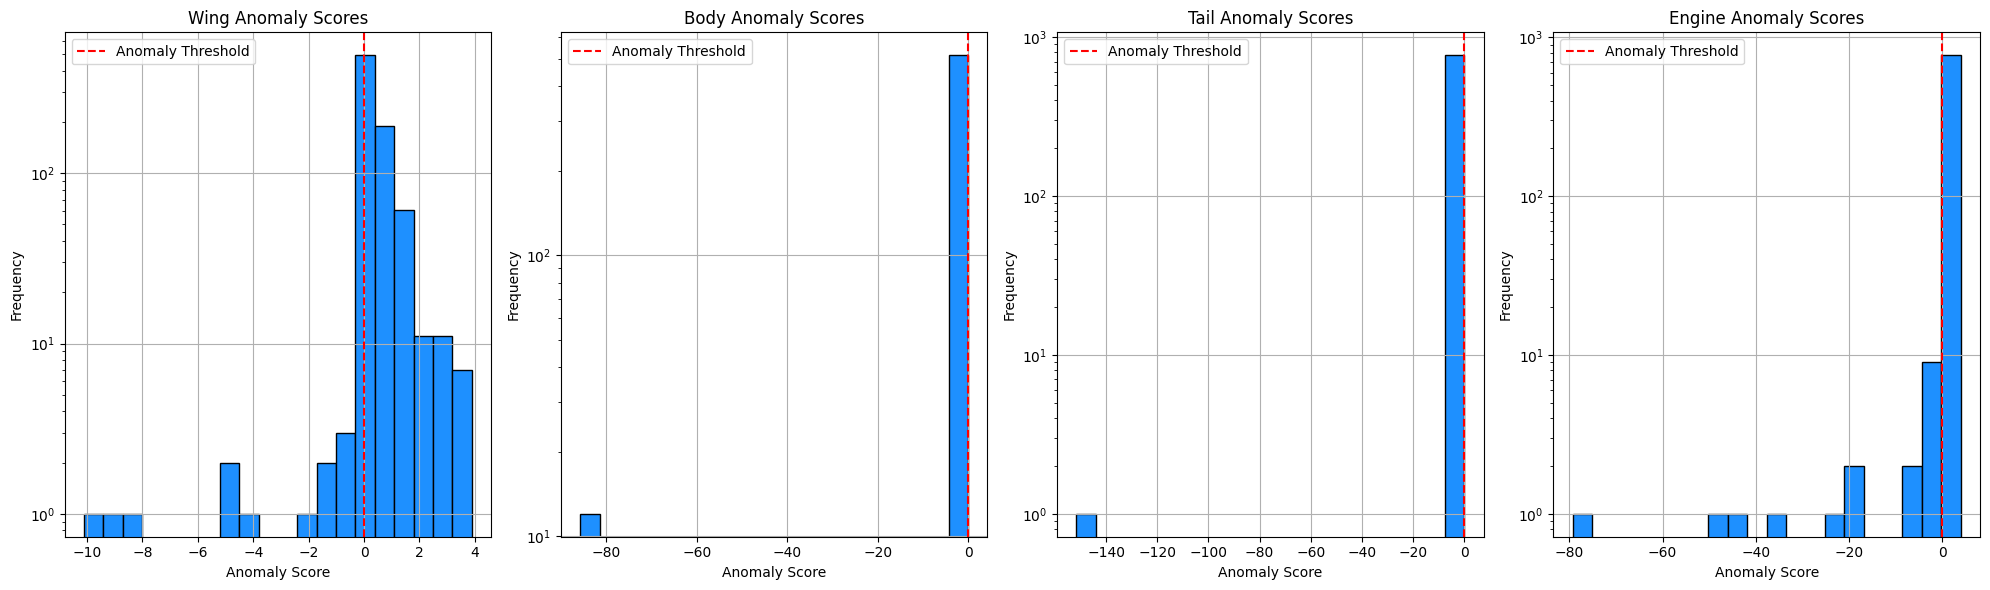

In [ ]:

# --- Count part occurrences in training and testing sets ---
train_file_counts = Counter({part: 0 for part in part_to_label})
test_file_counts = Counter({part: 0 for part in part_to_label})

for labels in train_labels:
    unique_labels = np.unique(labels)
    for label in unique_labels:
        if label in label_to_part:
            train_file_counts[label_to_part[label]] += 1

for labels in test_labels:
    unique_labels = np.unique(labels)
    for label in unique_labels:
        if label in label_to_part:
            test_file_counts[label_to_part[label]] += 1


print("Number of files containing each part:")
print("\nTraining Set:")
for part, count in train_file_counts.items():
    print(f"{part.capitalize()}: {count}")

print("\nTest Set:")
for part, count in test_file_counts.items():
    print(f"{part.capitalize()}: {count}")


# --- Evaluate and visualize anomaly scores on test set ---
anomaly_scores = {part: [] for part in part_to_label}

for pc, labels in zip(test_pcs, test_labels):
    for part, label in part_to_label.items():
        part_points = pc[labels == label]
        if part_points.shape[0] > 0:
            features = extract_features(part_points).reshape(1, -1)
            score = part_models[part].decision_function(features)[0]
            anomaly_scores[part].append(score)


plt.figure(figsize=(20, 6))
for i, (part, scores) in enumerate(anomaly_scores.items(), 1):
    plt.subplot(1, 4, i)
    plt.hist(scores, bins=20, color='dodgerblue', edgecolor='black')
    plt.title(f"{part.capitalize()} Anomaly Scores")
    plt.xlabel("Anomaly Score")
    plt.ylabel("Frequency")
    plt.axvline(x=0, color='red', linestyle='--', label='Anomaly Threshold')
    plt.legend()
    plt.yscale('log')
    plt.grid(True)

plt.tight_layout()
plt.show()